In [1]:
!pip -q install transformers
!pip -q install timm
!pip -q install accelerate
!pip -q install einops

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor
)

from tqdm import tqdm

In [3]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
DATASET_PATH = "/content/drive/MyDrive/CBIS_DDSM view preprocessing/Train_Val_Test"

In [9]:
X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "Y_train.npy"))
VIEW_train = np.load(os.path.join(DATASET_PATH, "VIEW_train.npy"))

X_val = np.load(os.path.join(DATASET_PATH, "X_val.npy"))
Y_val = np.load(os.path.join(DATASET_PATH, "Y_val.npy"))
VIEW_val = np.load(os.path.join(DATASET_PATH, "VIEW_val.npy"))

X_test = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "Y_test.npy"))
VIEW_test = np.load(os.path.join(DATASET_PATH, "VIEW_test.npy"))

In [10]:
print("="*60)

print("Training")
print(X_train.shape)
print(Y_train.shape)
print(VIEW_train.shape)

print()

print("Validation")
print(X_val.shape)
print(Y_val.shape)
print(VIEW_val.shape)

print()

print("Testing")
print(X_test.shape)
print(Y_test.shape)
print(VIEW_test.shape)

Training
(2592, 224, 224, 1)
(2592, 224, 224, 1)
(2592,)

Validation
(324, 224, 224, 1)
(324, 224, 224, 1)
(324,)

Testing
(325, 224, 224, 1)
(325, 224, 224, 1)
(325,)


In [11]:
print("Image dtype :", X_train.dtype)
print("Mask dtype  :", Y_train.dtype)

print()

print("Image Min :", X_train.min())
print("Image Max :", X_train.max())

print()

print("Mask Unique Values")
print(np.unique(Y_train))

Image dtype : float32
Mask dtype  : uint8

Image Min : 0.003921569
Image Max : 1.0

Mask Unique Values
[0 1]


In [12]:
print("Training")

unique, counts = np.unique(VIEW_train, return_counts=True)

for u, c in zip(unique, counts):
    print("CC" if u==0 else "MLO", c)

print()

print("Validation")

unique, counts = np.unique(VIEW_val, return_counts=True)

for u, c in zip(unique, counts):
    print("CC" if u==0 else "MLO", c)

print()

print("Testing")

unique, counts = np.unique(VIEW_test, return_counts=True)

for u, c in zip(unique, counts):
    print("CC" if u==0 else "MLO", c)

Training
CC 1219
MLO 1373

Validation
CC 152
MLO 172

Testing
CC 153
MLO 172


In [13]:
class CBISDataset(Dataset):

    def __init__(self, images, masks, views):

        self.images = images
        self.masks = masks
        self.views = views

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]          # (224,224,1)
        mask = self.masks[idx]            # (224,224,1)
        view = self.views[idx]            # 0(CC) / 1(MLO)

        # Already normalized
        image = image.astype(np.float32)

        # Convert grayscale -> RGB
        image = np.repeat(image, 3, axis=-1)

        # HWC -> CHW
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)

        # Mask
        mask = np.squeeze(mask)

        mask = torch.tensor(mask, dtype=torch.long)

        view = torch.tensor(view, dtype=torch.long)

        return image, mask, view

In [14]:
train_dataset = CBISDataset(
    X_train,
    Y_train,
    VIEW_train
)

val_dataset = CBISDataset(
    X_val,
    Y_val,
    VIEW_val
)

test_dataset = CBISDataset(
    X_test,
    Y_test,
    VIEW_test
)

In [15]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [16]:
images, masks, views = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)
print("Views  :", views.shape)

print()
print("Image dtype :", images.dtype)
print("Mask dtype  :", masks.dtype)

print()
print("Unique Mask Values :", torch.unique(masks))

print()
print("View Labels :", views[:10])

Images : torch.Size([8, 3, 224, 224])
Masks  : torch.Size([8, 224, 224])
Views  : torch.Size([8])

Image dtype : torch.float32
Mask dtype  : torch.int64

Unique Mask Values : tensor([0, 1])

View Labels : tensor([1, 0, 1, 1, 1, 0, 1, 0])


In [17]:
from transformers import SegformerForSemanticSegmentation

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model.to(device)

print("Model loaded successfully!")

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded successfully!


In [18]:
model.eval()

images, masks, views = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(pixel_values=images)

print("Output shape :", outputs.logits.shape)

Output shape : torch.Size([8, 2, 56, 56])


In [19]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Lesion class probability
        probs = probs[:, 1, :, :]

        targets = targets.float()

        intersection = (probs * targets).sum(dim=(1,2))

        union = probs.sum(dim=(1,2)) + targets.sum(dim=(1,2))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        loss = 1 - dice

        return loss.mean()

In [20]:
class HybridLoss(nn.Module):

    def __init__(self):

        super(HybridLoss, self).__init__()

        self.ce = nn.CrossEntropyLoss()

        self.dice = DiceLoss()

    def forward(self, logits, targets):

        ce_loss = self.ce(logits, targets)

        dice_loss = self.dice(logits, targets)

        total_loss = 0.5 * ce_loss + 0.5 * dice_loss

        return total_loss

In [21]:
criterion = HybridLoss()

In [22]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [28]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [29]:
scaler = torch.amp.GradScaler('cuda')

In [30]:
EPOCHS = 50

best_dice = 0.0

patience = 10

counter = 0

save_path = "/content/drive/MyDrive/SegFormer_B0_Best.pth"

In [39]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

def calculate_metrics(preds, targets, eps=1e-6):

    preds = (preds>0).float()
    targets = (targets>0).float()

    TP = (preds * targets).sum()

    FP = (preds * (1 - targets)).sum()

    FN = ((1 - preds) * targets).sum()

    TN = ((1 - preds) * (1 - targets)).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)

    precision = TP / (TP + FP + eps)

    recall = TP / (TP + FN + eps)

    dice = (2 * TP) / (2 * TP + FP + FN + eps)

    iou = TP / (TP + FP + FN + eps)

    f1 = dice

    return (
        accuracy.item(),
        dice.item(),
        iou.item(),
        precision.item(),
        recall.item(),
        f1.item()
    )

In [40]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    scaler,
                    device):

    model.train()

    running_loss = 0.0

    total_preds = []
    total_targets = []

    for images, masks, views in tqdm(loader):

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):

            outputs = model(pixel_values=images)

            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            loss = criterion(logits, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        total_preds.append(preds)
        total_targets.append(masks)

    total_preds = torch.cat(total_preds, dim=0)
    total_targets = torch.cat(total_targets, dim=0)

    metrics = calculate_metrics(total_preds, total_targets)

    return running_loss / len(loader), metrics

In [41]:
def validate(model,
             loader,
             criterion,
             device):

    model.eval()

    running_loss = 0.0

    total_preds = []
    total_targets = []

    cc_preds = []
    cc_targets = []

    mlo_preds = []
    mlo_targets = []

    with torch.no_grad():

        for images, masks, views in tqdm(loader):

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(pixel_values=images)

            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            loss = criterion(logits, masks)

            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            total_preds.append(preds)
            total_targets.append(masks)

            for i in range(len(views)):

                if views[i] == 0:

                    cc_preds.append(preds[i])
                    cc_targets.append(masks[i])

                else:

                    mlo_preds.append(preds[i])
                    mlo_targets.append(masks[i])

    total_preds = torch.cat(total_preds, dim=0)
    total_targets = torch.cat(total_targets, dim=0)

    metrics = calculate_metrics(total_preds, total_targets)

    cc_metrics = calculate_metrics(
        torch.stack(cc_preds),
        torch.stack(cc_targets)
    )

    mlo_metrics = calculate_metrics(
        torch.stack(mlo_preds),
        torch.stack(mlo_targets)
    )

    return (
        running_loss / len(loader),
        metrics,
        cc_metrics,
        mlo_metrics
    )

In [42]:
train_losses = []
val_losses = []

train_dices = []
val_dices = []

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "train_acc": [],
    "val_acc": []
}

In [47]:
for epoch in range(EPOCHS):

    print("=" * 80)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("=" * 80)

    # -------------------- Training --------------------
    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        device
    )

    # -------------------- Validation --------------------
    val_loss, val_metrics, cc_metrics, mlo_metrics = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_metrics[1])      # Validation Dice

    train_acc, train_dice, train_iou, train_prec, train_rec, train_f1 = train_metrics

    val_acc, val_dice, val_iou, val_prec, val_rec, val_f1 = val_metrics

    cc_acc, cc_dice, cc_iou, cc_prec, cc_rec, cc_f1 = cc_metrics

    mlo_acc, mlo_dice, mlo_iou, mlo_prec, mlo_rec, mlo_f1 = mlo_metrics

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print()

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print()

    print(f"CC Dice    : {cc_dice:.4f}")
    print(f"MLO Dice   : {mlo_dice:.4f}")

    print()

    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print()

    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    # -------------------- Save Best --------------------

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_dice": best_dice
        }, save_path)

        print("✅ Best model saved.")

    else:

        counter += 1

        print(f"\nEarly Stopping Counter : {counter}/{patience}")

    if counter >= patience:

        print("\nEarly stopping triggered.")

        break

Epoch [1/50]


100%|██████████| 41/41 [00:01<00:00, 30.82it/s]


Train Loss : 0.0946
Val Loss   : 0.2016

Train Dice : 0.9431
Val Dice   : 0.8940

CC Dice    : 0.8863
MLO Dice   : 0.9006

Train IoU  : 0.8924
Val IoU    : 0.8083

Train Acc  : 0.9546
Val Acc    : 0.9121
✅ Best model saved.
Epoch [2/50]


100%|██████████| 41/41 [00:01<00:00, 30.30it/s]


Train Loss : 0.0926
Val Loss   : 0.2025

Train Dice : 0.9443
Val Dice   : 0.8940

CC Dice    : 0.8865
MLO Dice   : 0.9005

Train IoU  : 0.8945
Val IoU    : 0.8083

Train Acc  : 0.9556
Val Acc    : 0.9124
✅ Best model saved.
Epoch [3/50]


...

Train Loss : 0.0867
Val Loss   : 0.2124

Train Dice : 0.9481
Val Dice   : 0.8934

CC Dice    : 0.8863
MLO Dice   : 0.8996

Train IoU  : 0.9013
Val IoU    : 0.8073

Train Acc  : 0.9586
Val Acc    : 0.9123

Early Stopping Counter : 8/10
Epoch [11/50]


100%|██████████| 41/41 [00:01<00:00, 22.54it/s]


Train Loss : 0.0859
Val Loss   : 0.2113

Train Dice : 0.9486
Val Dice   : 0.8936

CC Dice    : 0.8866
MLO Dice   : 0.8996

Train IoU  : 0.9021
Val IoU    : 0.8076

Train Acc  : 0.9590
Val Acc    : 0.9125

Early Stopping Counter : 9/10
Epoch [12/50]


100%|██████████| 41/41 [00:01<00:00, 31.42it/s]

Train Loss : 0.0859
Val Loss   : 0.2126

Train Dice : 0.9486
Val Dice   : 0.8939

CC Dice    : 0.8865
MLO Dice   : 0.9002

Train IoU  : 0.9022
Val IoU    : 0.8081

Train Acc  : 0.9590
Val Acc    : 0.9124

Early Stopping Counter : 10/10

Early stopping triggered.


In [48]:
checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

best_dice = checkpoint["best_dice"]

print("="*60)
print("Best Model Loaded Successfully")
print(f"Best Validation Dice : {best_dice:.4f}")
print("="*60)

Best Model Loaded Successfully
Best Validation Dice : 0.8940


In [49]:
def test_model(model,
               loader,
               device):

    model.eval()

    total_preds = []
    total_targets = []

    cc_preds = []
    cc_targets = []

    mlo_preds = []
    mlo_targets = []

    with torch.no_grad():

        for images, masks, views in tqdm(loader):

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(pixel_values=images)

            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            preds = torch.argmax(logits, dim=1)

            total_preds.append(preds)
            total_targets.append(masks)

            for i in range(len(views)):

                if views[i] == 0:

                    cc_preds.append(preds[i])
                    cc_targets.append(masks[i])

                else:

                    mlo_preds.append(preds[i])
                    mlo_targets.append(masks[i])

    total_preds = torch.cat(total_preds, dim=0)
    total_targets = torch.cat(total_targets, dim=0)

    metrics = calculate_metrics(total_preds, total_targets)

    cc_metrics = calculate_metrics(
        torch.stack(cc_preds),
        torch.stack(cc_targets)
    )

    mlo_metrics = calculate_metrics(
        torch.stack(mlo_preds),
        torch.stack(mlo_targets)
    )

    return metrics, cc_metrics, mlo_metrics

In [50]:
metrics, cc_metrics, mlo_metrics = test_model(
    model,
    test_loader,
    device
)

100%|██████████| 41/41 [00:01<00:00, 31.34it/s]


In [51]:
print("="*60)
print("OVERALL TEST RESULTS")
print("="*60)

print(f"Accuracy  : {metrics[0]:.4f}")
print(f"Dice      : {metrics[1]:.4f}")
print(f"IoU       : {metrics[2]:.4f}")
print(f"Precision : {metrics[3]:.4f}")
print(f"Recall    : {metrics[4]:.4f}")
print(f"F1 Score  : {metrics[5]:.4f}")

OVERALL TEST RESULTS
Accuracy  : 0.9148
Dice      : 0.8967
IoU       : 0.8127
Precision : 0.8843
Recall    : 0.9095
F1 Score  : 0.8967


In [52]:
print("="*60)
print("CC VIEW RESULTS")
print("="*60)

print(f"Accuracy  : {cc_metrics[0]:.4f}")
print(f"Dice      : {cc_metrics[1]:.4f}")
print(f"IoU       : {cc_metrics[2]:.4f}")
print(f"Precision : {cc_metrics[3]:.4f}")
print(f"Recall    : {cc_metrics[4]:.4f}")
print(f"F1 Score  : {cc_metrics[5]:.4f}")

CC VIEW RESULTS
Accuracy  : 0.9096
Dice      : 0.8916
IoU       : 0.8044
Precision : 0.8762
Recall    : 0.9075
F1 Score  : 0.8916


In [53]:
print("="*60)
print("MLO VIEW RESULTS")
print("="*60)

print(f"Accuracy  : {mlo_metrics[0]:.4f}")
print(f"Dice      : {mlo_metrics[1]:.4f}")
print(f"IoU       : {mlo_metrics[2]:.4f}")
print(f"Precision : {mlo_metrics[3]:.4f}")
print(f"Recall    : {mlo_metrics[4]:.4f}")
print(f"F1 Score  : {mlo_metrics[5]:.4f}")

MLO VIEW RESULTS
Accuracy  : 0.9194
Dice      : 0.9013
IoU       : 0.8204
Precision : 0.8917
Recall    : 0.9112
F1 Score  : 0.9013


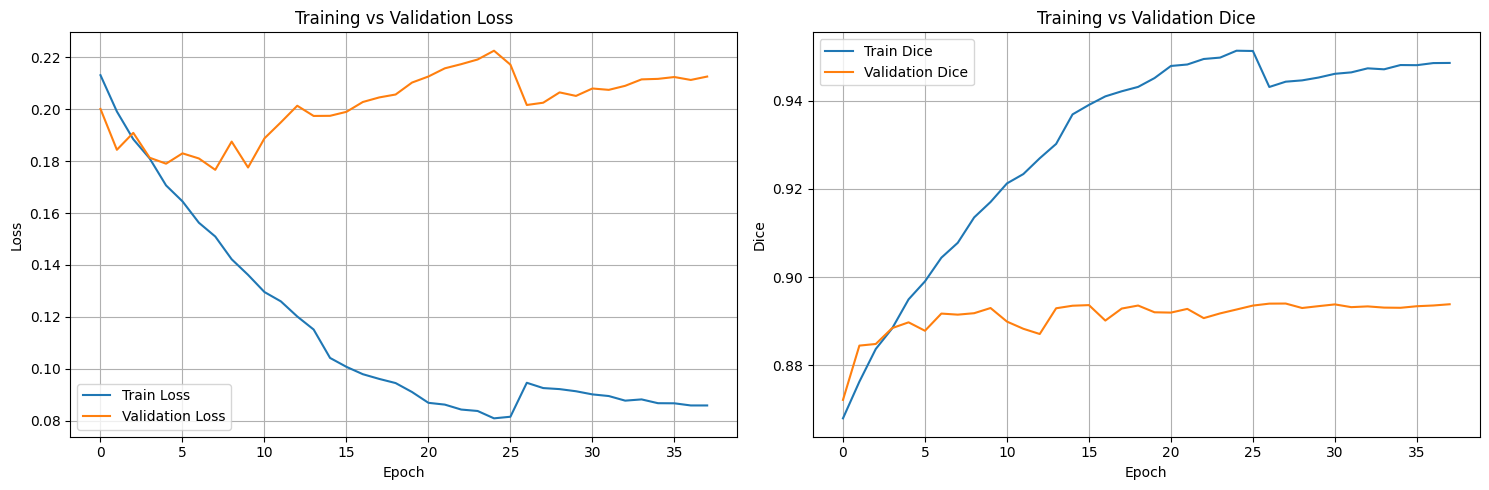

In [54]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.subplot(1,2,2)

plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice")

plt.title("Training vs Validation Dice")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [55]:
def create_overlap(image, gt, pred):

    image = image.astype(np.float32)

    if image.max() > 1:
        image = image / 255.0

    rgb = np.stack([image]*3, axis=-1)

    overlay = rgb.copy()

    TP = (gt == 1) & (pred == 1)
    FP = (gt == 0) & (pred == 1)
    FN = (gt == 1) & (pred == 0)

    # True Positive → Green
    overlay[TP] = [0, 1, 0]

    # False Positive → Red
    overlay[FP] = [1, 0, 0]

    # False Negative → Blue
    overlay[FN] = [0, 0, 1]

    return overlay

In [57]:
def dice_score_per_image(pred, target, eps=1e-6):

    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    intersection = (pred * target).sum()

    dice = (2.0 * intersection + eps) / (
        pred.sum() + target.sum() + eps
    )

    return dice

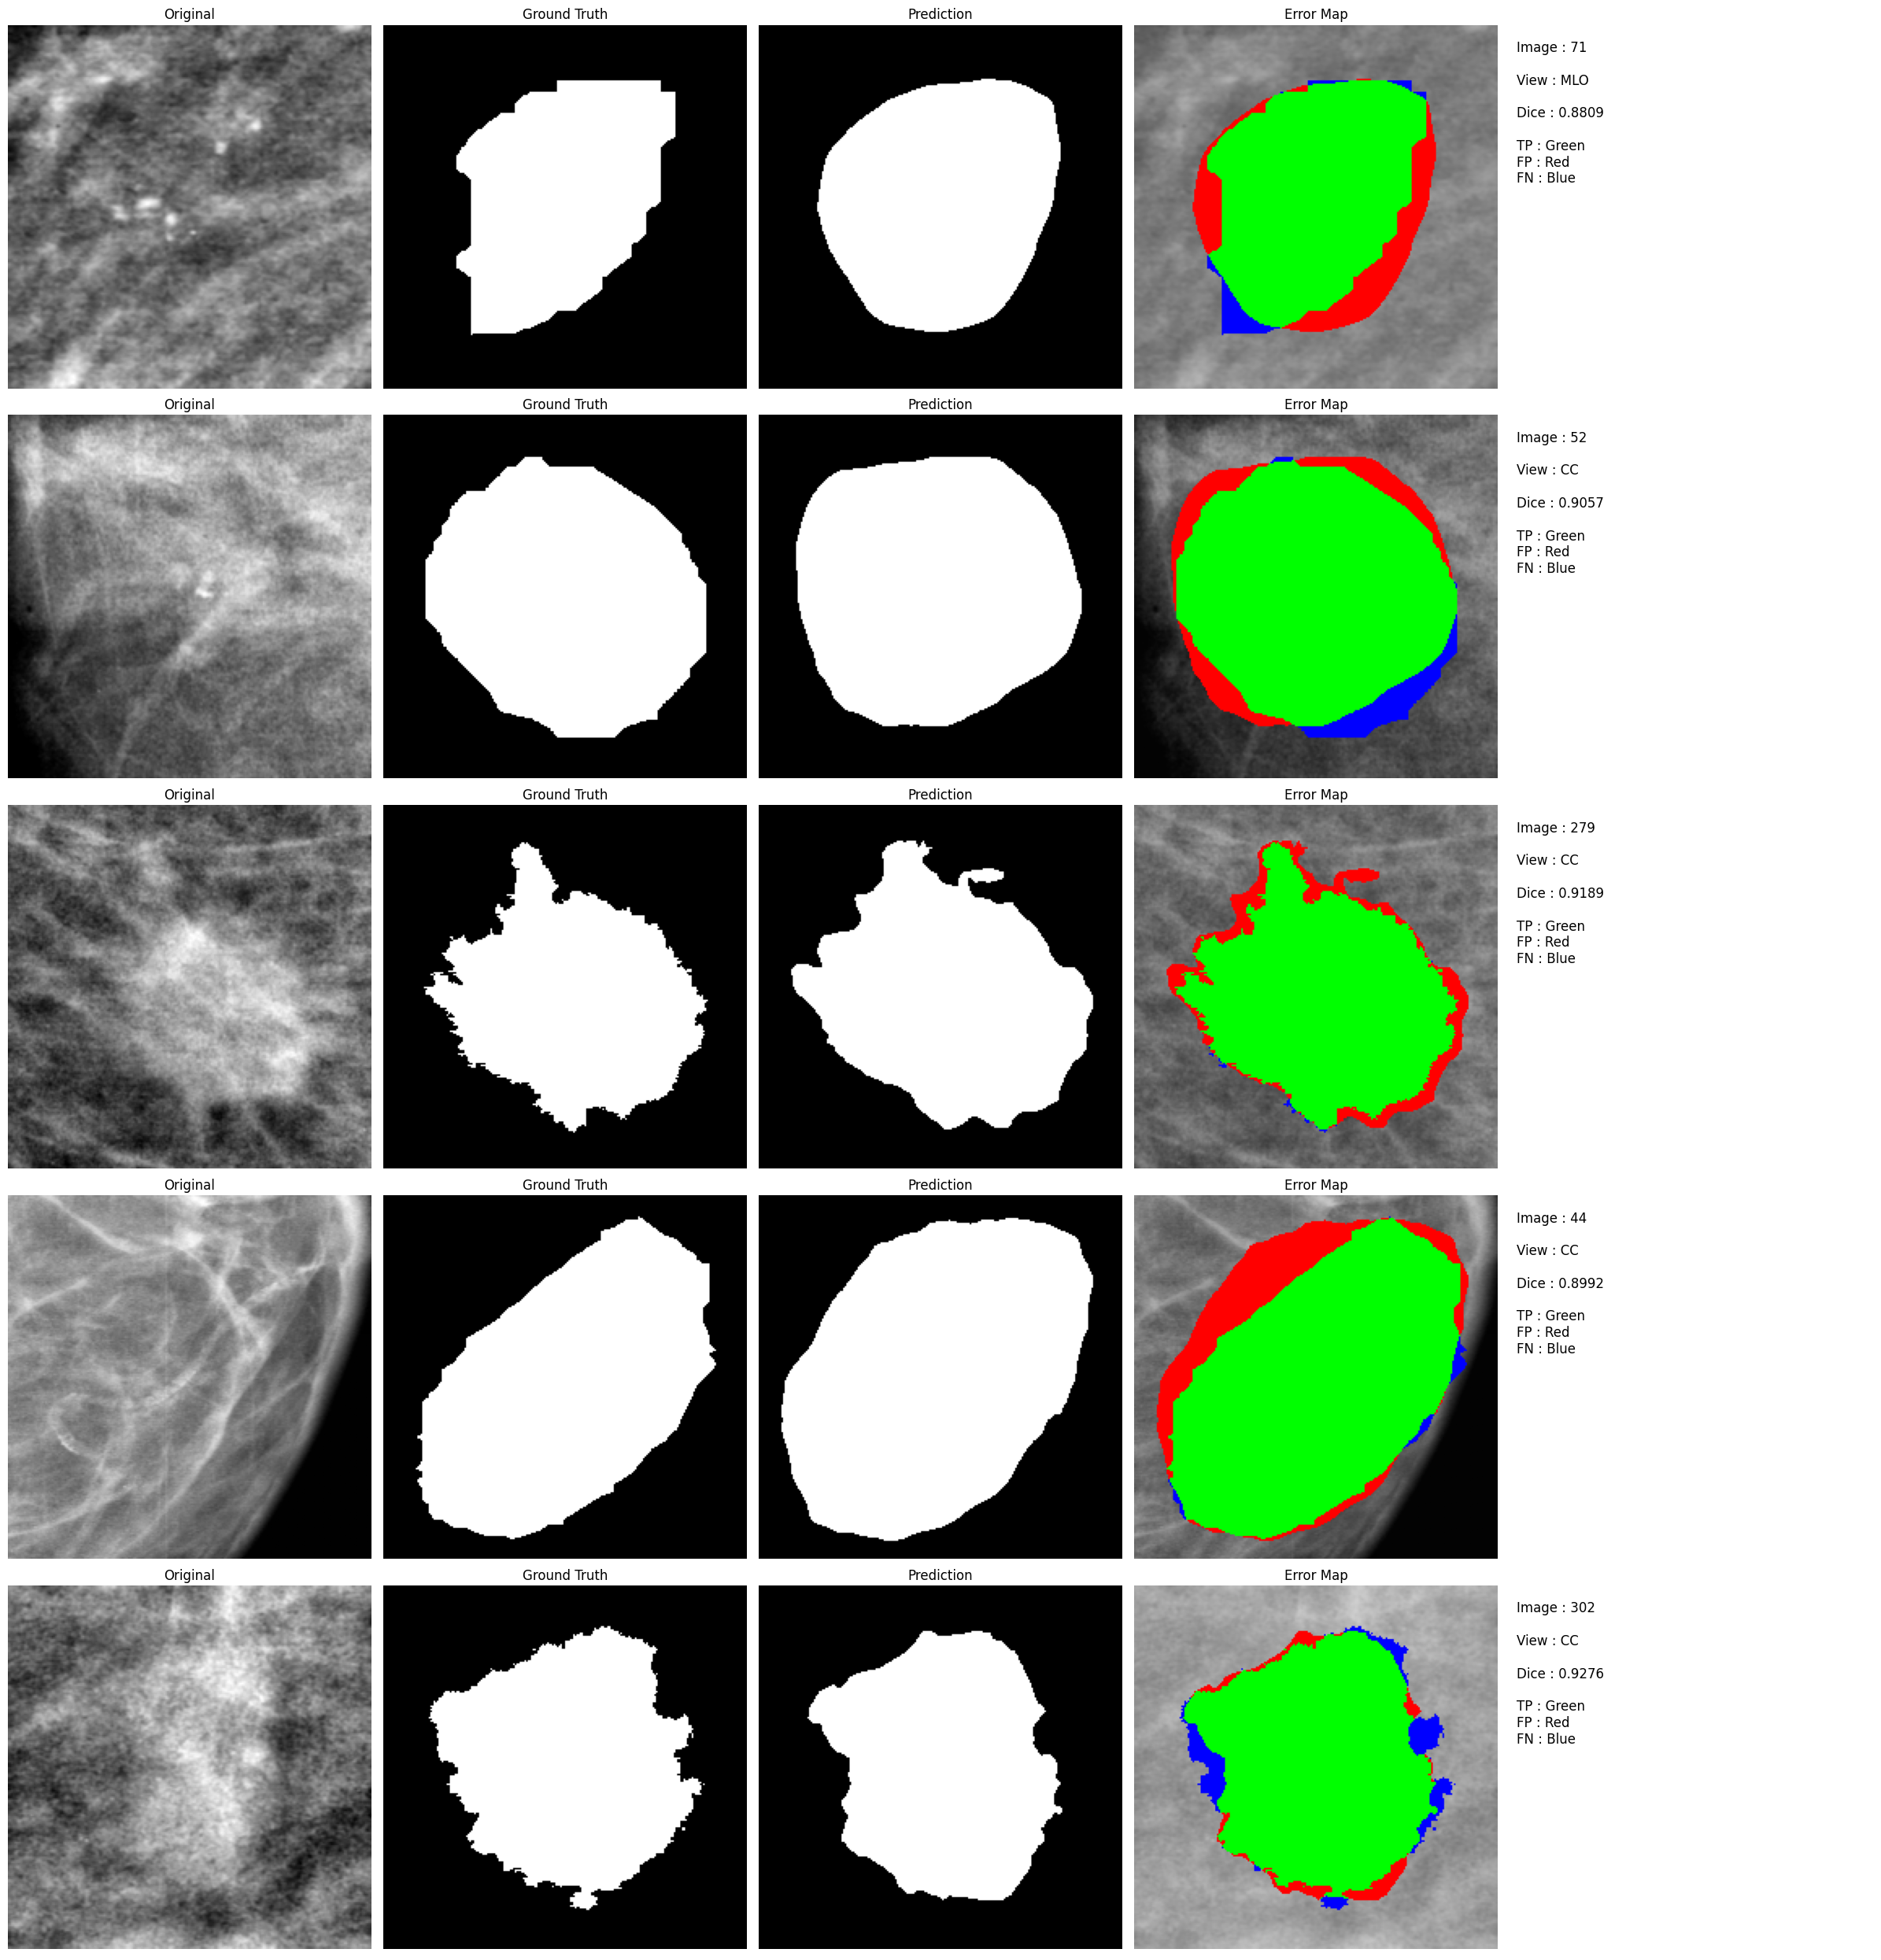

In [58]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

model.eval()

num_images = 5

indices = random.sample(range(len(test_dataset)), num_images)

fig, axes = plt.subplots(num_images, 5, figsize=(24, 5*num_images))

with torch.no_grad():

    for row, idx in enumerate(indices):

        image, mask, view = test_dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        output = model(pixel_values=input_tensor)

        logits = F.interpolate(
            output.logits,
            size=(224,224),
            mode="bilinear",
            align_corners=False
        )

        pred = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

        image_np = image.permute(1,2,0).numpy()[:,:,0]

        gt = mask.numpy()

        dice = dice_score_per_image(pred, gt)

        overlay = create_overlap(image_np, gt, pred)

        # ---------------- Original ----------------

        axes[row,0].imshow(image_np, cmap="gray")
        axes[row,0].set_title("Original", fontsize=12)
        axes[row,0].axis("off")

        # ---------------- GT ----------------

        axes[row,1].imshow(gt, cmap="gray")
        axes[row,1].set_title("Ground Truth", fontsize=12)
        axes[row,1].axis("off")

        # ---------------- Prediction ----------------

        axes[row,2].imshow(pred, cmap="gray")
        axes[row,2].set_title("Prediction", fontsize=12)
        axes[row,2].axis("off")

        # ---------------- Overlay ----------------

        axes[row,3].imshow(overlay)
        axes[row,3].set_title("Error Map", fontsize=12)
        axes[row,3].axis("off")

        # ---------------- Information ----------------

        axes[row,4].axis("off")

        info = (
            f"Image : {idx}\n\n"
            f"View : {'CC' if view.item()==0 else 'MLO'}\n\n"
            f"Dice : {dice:.4f}\n\n"
            f"TP : Green\n"
            f"FP : Red\n"
            f"FN : Blue"
        )

        axes[row,4].text(
            0.02,
            0.95,
            info,
            fontsize=12,
            va="top"
        )

plt.tight_layout()

plt.show()

In [60]:
def evaluate_model(model, loader, device, criterion=None):

    model.eval()

    running_loss = 0.0

    total_preds = []
    total_targets = []

    cc_preds = []
    cc_targets = []

    mlo_preds = []
    mlo_targets = []

    with torch.no_grad():

        for images, masks, views in loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(pixel_values=images)

            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            if criterion is not None:
                loss = criterion(logits, masks)
                running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            total_preds.append(preds)
            total_targets.append(masks)

            for i in range(len(views)):

                if views[i] == 0:
                    cc_preds.append(preds[i])
                    cc_targets.append(masks[i])
                else:
                    mlo_preds.append(preds[i])
                    mlo_targets.append(masks[i])

    total_preds = torch.cat(total_preds)
    total_targets = torch.cat(total_targets)

    cc_preds = torch.stack(cc_preds)
    cc_targets = torch.stack(cc_targets)

    mlo_preds = torch.stack(mlo_preds)
    mlo_targets = torch.stack(mlo_targets)

    overall_metrics = calculate_metrics(total_preds, total_targets)
    cc_metrics = calculate_metrics(cc_preds, cc_targets)
    mlo_metrics = calculate_metrics(mlo_preds, mlo_targets)

    avg_loss = running_loss / len(loader) if criterion else None

    return avg_loss, overall_metrics, cc_metrics, mlo_metrics

In [61]:
train_loss, train_overall, train_cc, train_mlo = evaluate_model(
    model,
    train_loader,
    device,
    criterion
)

val_loss, val_overall, val_cc, val_mlo = evaluate_model(
    model,
    val_loader,
    device,
    criterion
)

test_loss, test_overall, test_cc, test_mlo = evaluate_model(
    model,
    test_loader,
    device,
    criterion
)

In [62]:
import pandas as pd

results = [

    ["Train","Overall",train_loss,*train_overall],
    ["Train","CC",train_loss,*train_cc],
    ["Train","MLO",train_loss,*train_mlo],

    ["Validation","Overall",val_loss,*val_overall],
    ["Validation","CC",val_loss,*val_cc],
    ["Validation","MLO",val_loss,*val_mlo],

    ["Test","Overall",test_loss,*test_overall],
    ["Test","CC",test_loss,*test_cc],
    ["Test","MLO",test_loss,*test_mlo],

]

columns = [
    "Dataset",
    "View",
    "Loss",
    "Accuracy",
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "F1 Score"
]

results_df = pd.DataFrame(results, columns=columns)

results_df.iloc[:,2:] = results_df.iloc[:,2:].round(4)

results_df

,Dataset,View,Loss,Accuracy,Dice,IoU,Precision,Recall,F1 Score
0,Train,Overall,0.0800,0.9617,0.9525,0.9092,0.9431,0.9621,0.9525
1,Train,CC,0.0800,0.9619,0.9528,0.9098,0.9437,0.9620,0.9528
2,Train,MLO,0.0800,0.9616,0.9522,0.9088,0.9424,0.9622,0.9522
3,Validation,Overall,0.2025,0.9124,0.8940,0.8083,0.8753,0.9135,0.8940
4,Validation,CC,0.2025,0.9072,0.8865,0.7961,0.8608,0.9137,0.8865
5,Validation,MLO,0.2025,0.9170,0.9005,0.8191,0.8881,0.9134,0.9005
6,Test,Overall,0.1962,0.9148,0.8967,0.8127,0.8843,0.9095,0.8967
7,Test,CC,0.1962,0.9096,0.8916,0.8044,0.8762,0.9075,0.8916
8,Test,MLO,0.1962,0.9194,0.9013,0.8204,0.8917,0.9112,0.9013


In [63]:
results_df.to_csv("SegFormer_B0_Complete_Results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
